In [1]:
import sys
import os
sys.path.insert(0, os.path.abspath(os.path.join('..')))

In [2]:
import torch
import torch.nn as nn
import pandas as pd
import numpy as np
import optuna
from src.preprocessing import process_dataframe
from sklearn.preprocessing import StandardScaler
from torch.utils.data import TensorDataset, DataLoader
from src._lstm import LSTMRegressor, train_lstm_recursive_val, predict
from src.visualization import plot_forecast
from sklearn.metrics import root_mean_squared_error

C:\Users\Ivan\AppData\Roaming\Python\Python312\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
df_train_full = pd.read_csv('../data/processed/train_raw, ZK 68, (48-1, 48-air), 27.11.20-31.12.24.csv', parse_dates=['Дата'])
df_train_full.index = df_train_full['Дата']

df_test = pd.read_csv('../data/processed/test_raw, ZK 68, (48-1, 48-air), 01.01.25-15.12.25.csv', parse_dates=['Дата'])
df_test.index = df_test['Дата']

df_train = df_train_full[:'2023-12-31'].copy()
df_val = df_train_full['2024-01-01':].copy()

In [4]:
df_train_full = process_dataframe(df_train_full)
df_train = process_dataframe(df_train)
df_val = process_dataframe(df_val)
df_test = process_dataframe(df_test)

In [5]:
target_cols = ['48-1 (0)', '48-1 (1)', '48-1 (2)',
               '48-1 (3)', '48-1 (4)', '48-1 (5)', '48-1 (6)',
               '48-1 (7)', '48-1 (8)', '48-1 (9)', '48-1 (10)', '48-1 (11)']
features_cols = ['Месяц_sin', 'Месяц_cos', 'day_of_year_sin', 
                 'day_of_year_cos', 'days_from_start', 'is_anomaly']
lags_length = 14

df_train_full = df_train_full[features_cols + target_cols]
df_train = df_train[features_cols + target_cols]
df_val = df_val[features_cols + target_cols]
df_test = df_test[features_cols + target_cols]

In [6]:
feature_scaler = StandardScaler()
target_scaler = StandardScaler()

train_features_scaled = feature_scaler.fit_transform(df_train[features_cols])
train_target_scaled = target_scaler.fit_transform(df_train[target_cols])

train_scaled = np.hstack((train_features_scaled, train_target_scaled))

val_start = df_train[-lags_length:]
df_full_val = pd.concat([val_start, df_val])

val_features_scaled = feature_scaler.transform(df_full_val[features_cols])
val_target_scaled = target_scaler.transform(df_full_val[target_cols])

val_scaled = np.hstack((val_features_scaled, val_target_scaled))

In [7]:
full_feature_scaler = StandardScaler()
full_target_scaler = StandardScaler()

full_train_features_scaled = full_feature_scaler.fit_transform(df_train_full[features_cols])
full_train_target_scaled = full_target_scaler.fit_transform(df_train_full[target_cols])

full_train_scaled = np.hstack((full_train_features_scaled, full_train_target_scaled))

In [8]:
def create_sequences(data, target_start_index, lags_length):
    X, y = [], []
    for i in range(len(data) - lags_length):
        X.append(data[i : i + lags_length])
        y.append(data[i + lags_length, target_start_index:])
    return torch.tensor(np.array(X), dtype=torch.float32), torch.tensor(np.array(y), dtype=torch.float32)

target_start_index = len(features_cols)

X_train, y_train = create_sequences(train_scaled, target_start_index, lags_length)
X_val, y_val = create_sequences(val_scaled, target_start_index, lags_length)
X_full_train, y_full_train = create_sequences(full_train_scaled, target_start_index, lags_length)

In [9]:
batch_size = 32
train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=batch_size)
val_loader = DataLoader(TensorDataset(X_val, y_val), batch_size=batch_size)
full_train_loader = DataLoader(TensorDataset(X_full_train, y_full_train), batch_size=batch_size)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [10]:
input_size = train_scaled.shape[1]
output_size = len(target_cols)
criterion = nn.MSELoss()

def objective(trial):
    hidden_size = trial.suggest_int('hidden_size', 16, 112, step=16)
    num_layers = trial.suggest_int('num_layers', 1, 3)
    lr = trial.suggest_float('lr', 1e-5, 1e-2, log=True)
    
    model_trial = LSTMRegressor(input_size, hidden_size, num_layers, output_size=output_size).to(device)
    optimizer_trial = torch.optim.Adam(model_trial.parameters(), lr=lr)

    model_trial, val_hist = train_lstm_recursive_val(
        model=model_trial,
        criterion=criterion,
        optimizer=optimizer_trial,
        train_loader=train_loader,
        val_loader=val_loader,
        target_scaler=target_scaler,
        device=device,
        epochs=50,
        max_epochs_no_improvement=10,
        verbose=False
    )
    
    trial.set_user_attr('total_epochs', len(val_hist) - 1)

    best_val_rmse = min(val_hist)
    return best_val_rmse

study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=10)

print("Лучшие параметры: ", study.best_params)
print("Количество эпох в лучшем запуске: ", study.best_trial.user_attrs['total_epochs'])

[I 2026-05-28 12:20:39,311] A new study created in memory with name: no-name-886e5da1-44eb-4438-bbf7-4804161722fb
[I 2026-05-28 12:20:54,660] Trial 0 finished with value: 2.5408718585968018 and parameters: {'hidden_size': 32, 'num_layers': 3, 'lr': 1.7325457193473304e-05}. Best is trial 0 with value: 2.5408718585968018.
[I 2026-05-28 12:20:58,816] Trial 1 finished with value: 0.8102202415466309 and parameters: {'hidden_size': 64, 'num_layers': 2, 'lr': 0.0011316407267741879}. Best is trial 1 with value: 0.8102202415466309.


Early stopping on 13 epoch


[I 2026-05-28 12:21:06,642] Trial 2 finished with value: 2.8945140838623047 and parameters: {'hidden_size': 32, 'num_layers': 1, 'lr': 1.6119775440203032e-05}. Best is trial 1 with value: 0.8102202415466309.
[I 2026-05-28 12:21:17,779] Trial 3 finished with value: 2.9234158992767334 and parameters: {'hidden_size': 16, 'num_layers': 2, 'lr': 1.3619220839858098e-05}. Best is trial 1 with value: 0.8102202415466309.
[I 2026-05-28 12:21:27,777] Trial 4 finished with value: 0.7882147431373596 and parameters: {'hidden_size': 80, 'num_layers': 3, 'lr': 0.0004341840852700551}. Best is trial 4 with value: 0.7882147431373596.


Early stopping on 18 epoch


[I 2026-05-28 12:21:37,013] Trial 5 finished with value: 0.7968437671661377 and parameters: {'hidden_size': 48, 'num_layers': 2, 'lr': 0.0038725677519317494}. Best is trial 4 with value: 0.7882147431373596.


...

Early stopping on 16 epoch


[I 2026-05-28 12:21:58,480] Trial 7 finished with value: 0.971144437789917 and parameters: {'hidden_size': 80, 'num_layers': 2, 'lr': 0.00010316528449655978}. Best is trial 4 with value: 0.7882147431373596.
[I 2026-05-28 12:22:01,861] Trial 8 finished with value: 0.83901447057724 and parameters: {'hidden_size': 80, 'num_layers': 1, 'lr': 0.0014752009441926055}. Best is trial 4 with value: 0.7882147431373596.


Early stopping on 14 epoch


[I 2026-05-28 12:22:17,086] Trial 9 finished with value: 2.447361707687378 and parameters: {'hidden_size': 48, 'num_layers': 2, 'lr': 1.4437475350755046e-05}. Best is trial 4 with value: 0.7882147431373596.


Лучшие параметры:  {'hidden_size': 80, 'num_layers': 3, 'lr': 0.0004341840852700551}
Количество эпох в лучшем запуске:  18


In [11]:
#input_size = full_train_scaled.shape[1]
model = LSTMRegressor(
    input_size=input_size,
    hidden_size=study.best_params['hidden_size'],
    num_layers=study.best_params['num_layers'],
    output_size=output_size
).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=study.best_params['lr'])

model, _ = train_lstm_recursive_val(
    model=model,
    criterion=criterion,
    optimizer=optimizer,
    train_loader=train_loader,
    device=device,
    epochs=study.best_trial.user_attrs['total_epochs'],
    max_epochs_no_improvement=10,
    verbose=True
)

Epoch 1/18, Train Loss: 0.9653
Epoch 2/18, Train Loss: 0.5276
Epoch 3/18, Train Loss: 0.2591
Epoch 4/18, Train Loss: 0.1918
Epoch 5/18, Train Loss: 0.1338
Epoch 6/18, Train Loss: 0.1029
Epoch 7/18, Train Loss: 0.0737
Epoch 8/18, Train Loss: 0.0531
Epoch 9/18, Train Loss: 0.0532
Epoch 10/18, Train Loss: 0.0811
Epoch 11/18, Train Loss: 0.0809
Epoch 12/18, Train Loss: 0.0528
Epoch 13/18, Train Loss: 0.0523
Epoch 14/18, Train Loss: 0.0279
Epoch 15/18, Train Loss: 0.0342
Epoch 16/18, Train Loss: 0.0207
Epoch 17/18, Train Loss: 0.0260
Epoch 18/18, Train Loss: 0.0200


In [ ]:
model_path = "models/lstm_v3_1.pth"
weights_path = "models/lstm_v3_weights_1.pth"

In [13]:
torch.save(model, model_path)
torch.save(model.state_dict(), weights_path)

In [14]:
model = torch.load(model_path, weights_only=False)

Test RMSE: 1.1317
RMSE for 48-1 (0): 5.3626


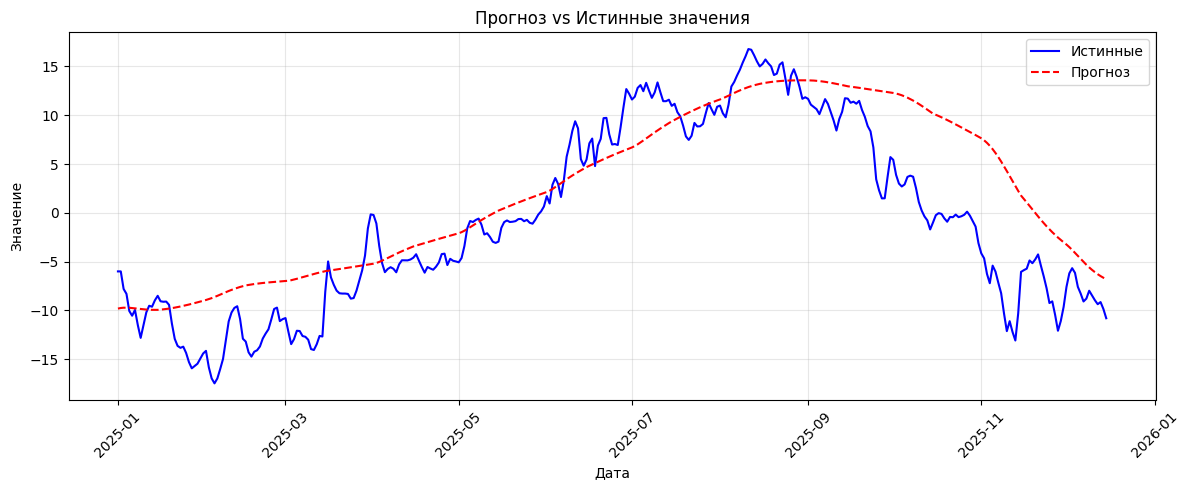

RMSE for 48-1 (1): 2.4144


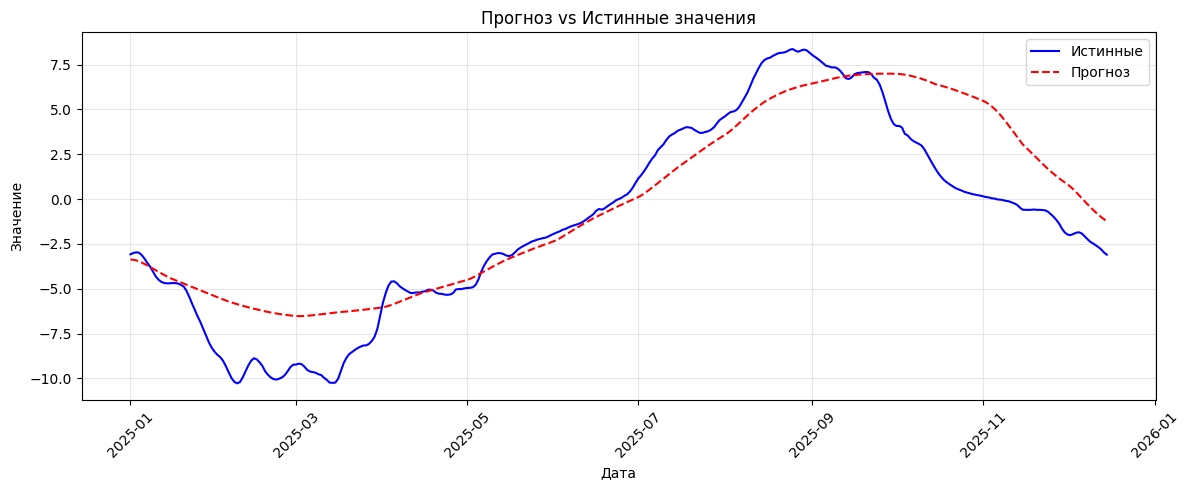

RMSE for 48-1 (2): 1.2618


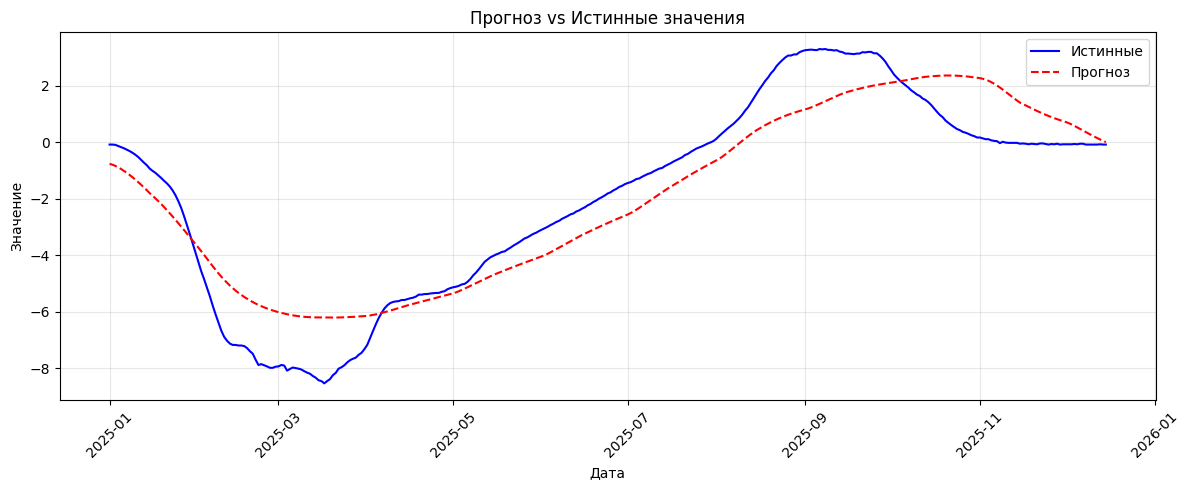

RMSE for 48-1 (3): 0.7946


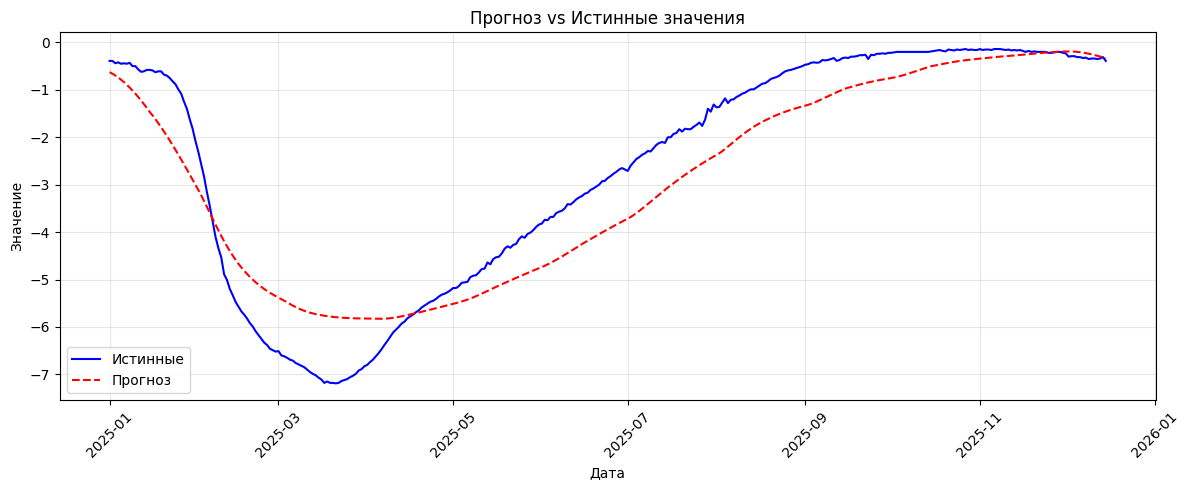

RMSE for 48-1 (4): 0.6953


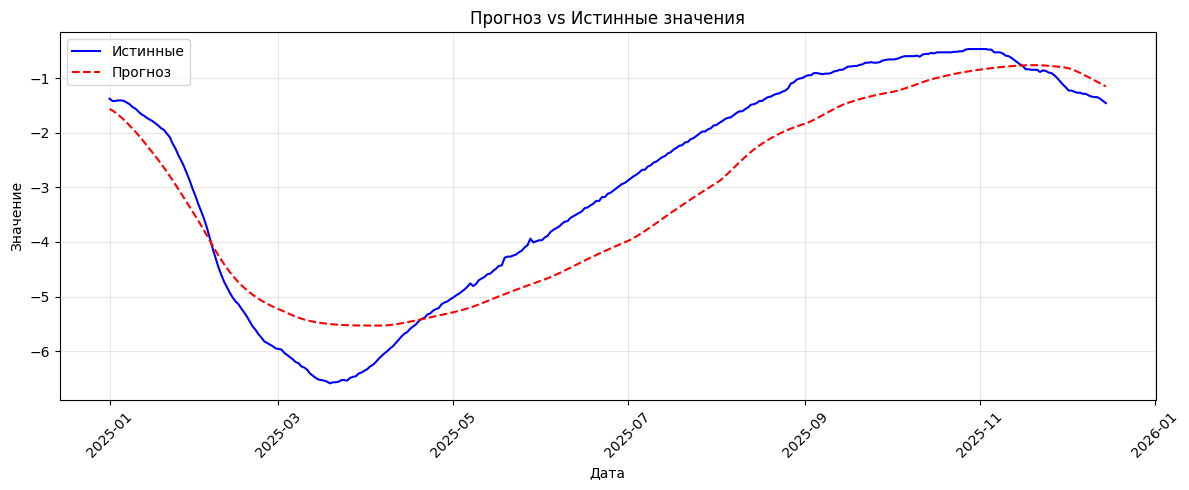

RMSE for 48-1 (5): 0.6669


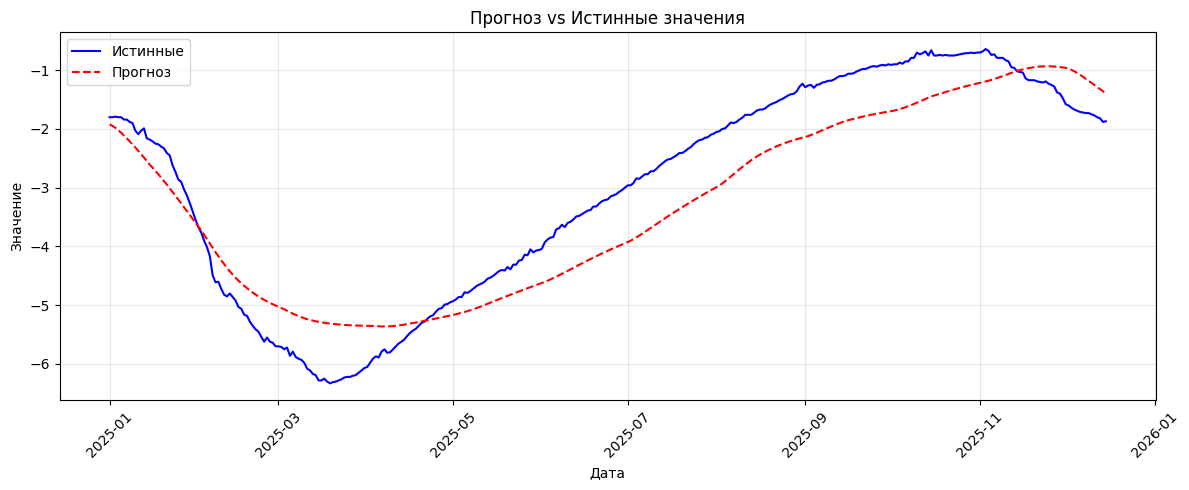

RMSE for 48-1 (6): 0.5908


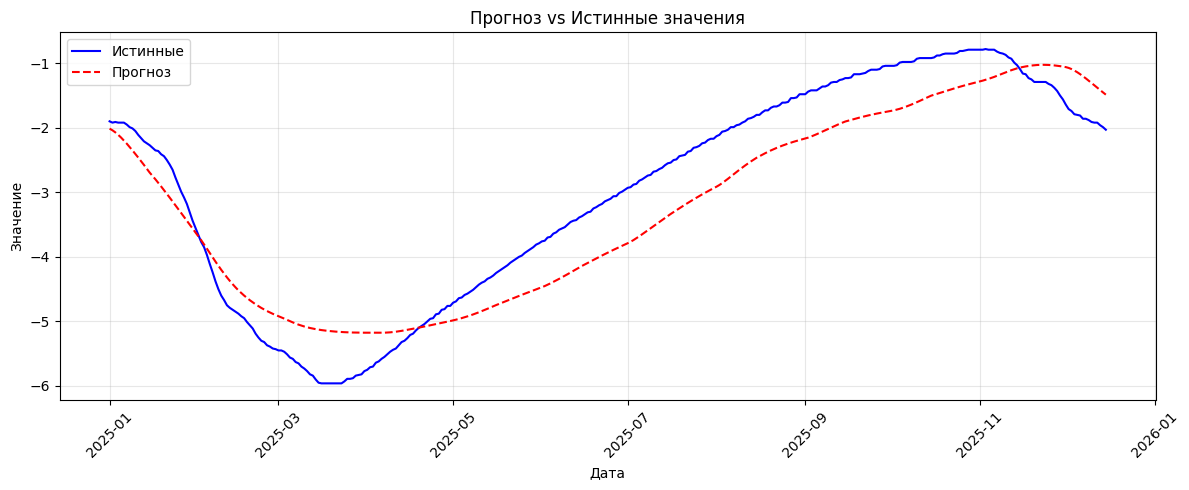

RMSE for 48-1 (7): 0.5545


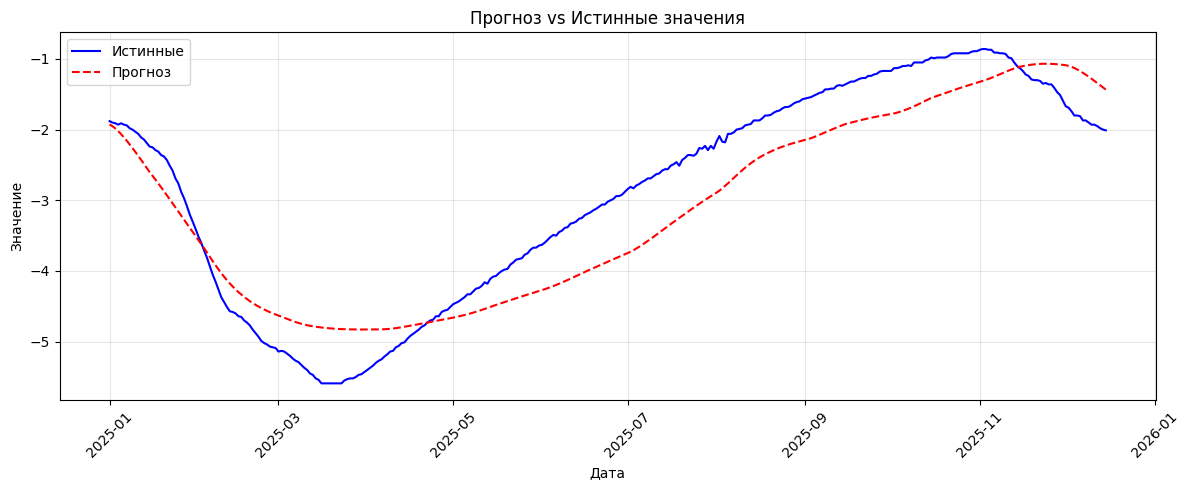

RMSE for 48-1 (8): 0.4754


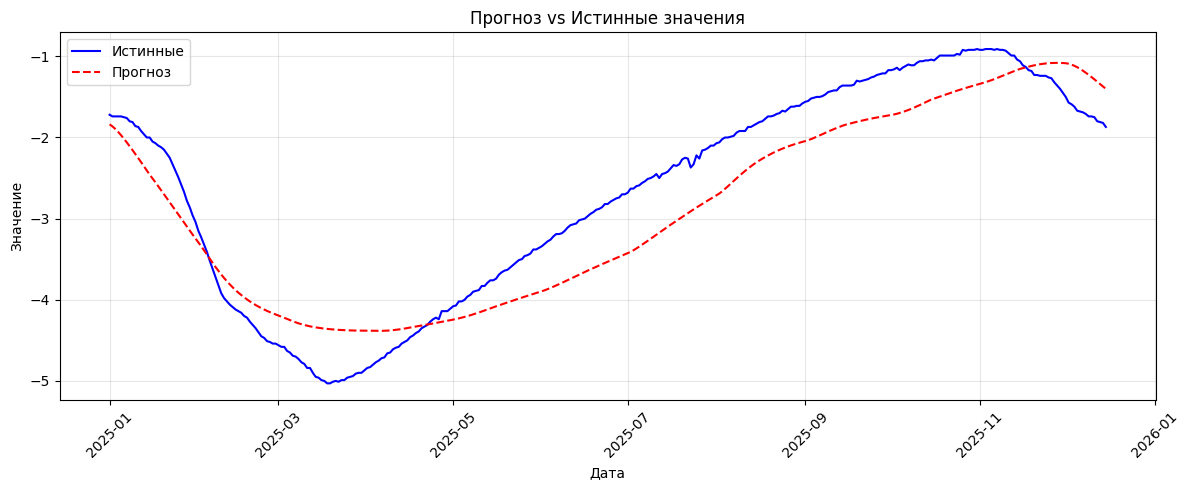

RMSE for 48-1 (9): 0.3335


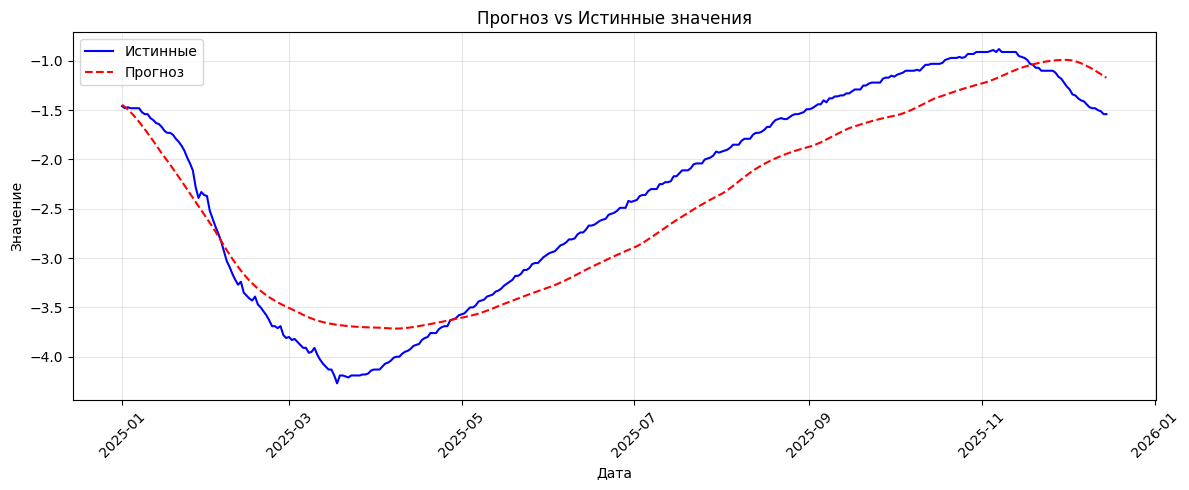

RMSE for 48-1 (10): 0.2340


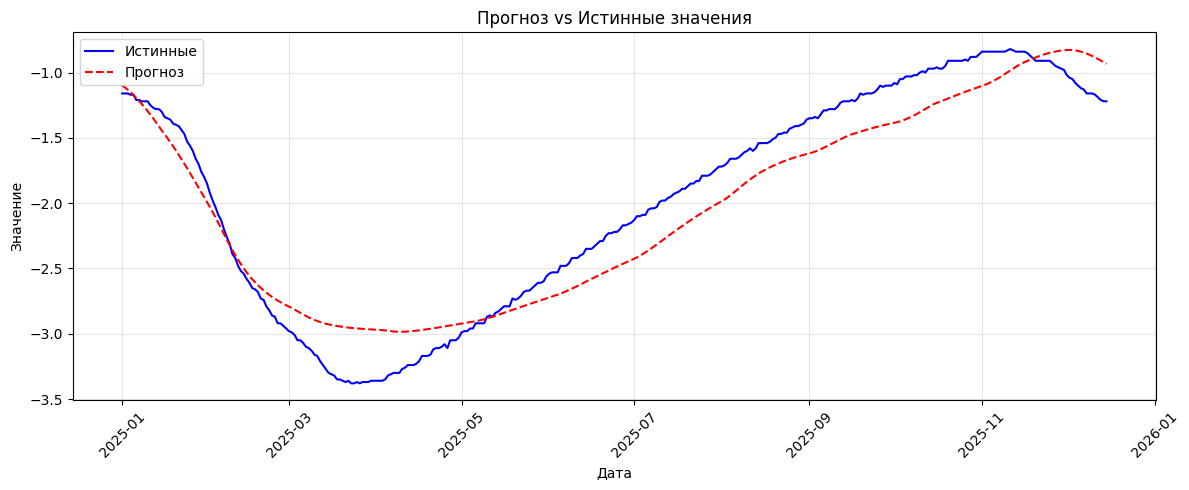

RMSE for 48-1 (11): 0.1965


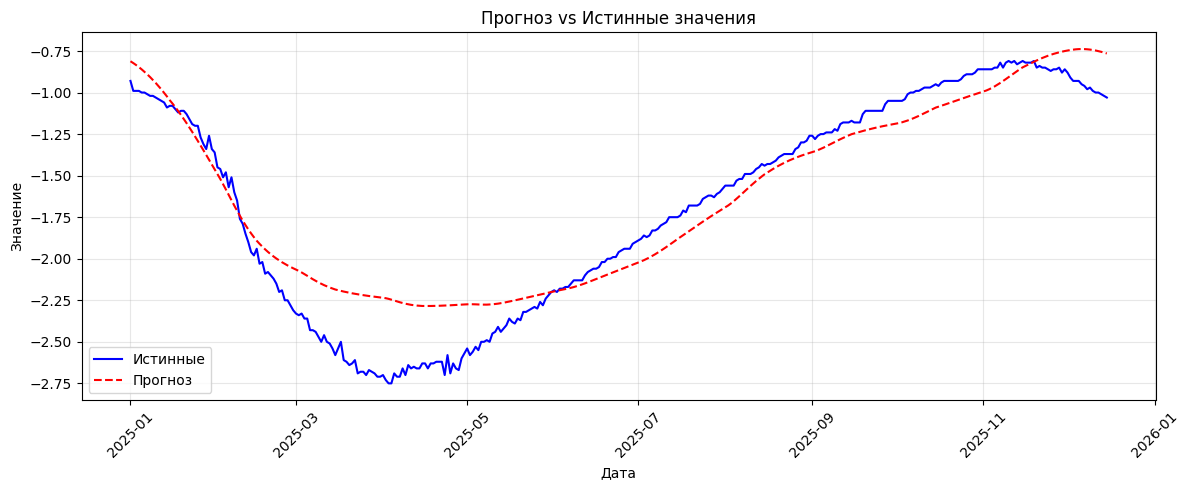

In [15]:
test_start = df_train_full[-lags_length:]

start_features_scaled = feature_scaler.transform(test_start[features_cols])
start_target_scaled = target_scaler.transform(test_start[target_cols])

current_lags = np.hstack((start_features_scaled, start_target_scaled))

future_features_scaled = feature_scaler.transform(df_test[features_cols])

start_lags_tensor = torch.tensor(current_lags, dtype=torch.float32)
future_features_tensor = torch.tensor(future_features_scaled, dtype=torch.float32)

y_pred_scaled = predict(model, start_lags_tensor, future_features_tensor, device=device)

y_pred = target_scaler.inverse_transform(y_pred_scaled)
y_true = df_test[target_cols].values

rmse = root_mean_squared_error(y_true, y_pred)
print(f"Test RMSE: {rmse:.4f}")

rmse_per_depth = root_mean_squared_error(y_true, y_pred, multioutput='raw_values')
for i, col in enumerate(target_cols):
    rmse = rmse_per_depth[i]
    print(f'RMSE for {col}: {rmse:.4f}')
    
    s_true = pd.Series(y_true[:, i], index=df_test.index)
    s_pred = pd.Series(y_pred[:, i], index=df_test.index)
    
    plot_forecast(pd.DataFrame(s_true), pd.DataFrame(s_pred))